### load the data

In [2]:
import pandas as pd

train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

print(train.shape)
train.head()

(40000, 184)


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,...,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,liquidity_stress_next_30d,ID
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,8,58372.55,...,0.00,0.0,12488.72,11404.86,12943.70,14157.61,13202.11,4336.98,1,ID_C1DF84C4D2
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0,0.00,...,5191.14,4.0,13677.61,2781.25,5897.59,5416.23,11062.23,4849.68,0,ID_CB8B764D76
2,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,12,41262.86,...,0.00,0.0,7271.09,5364.41,9023.13,13001.02,17107.92,15174.32,1,ID_D40D58FC67
3,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,10,8738.58,...,8965.63,3.0,14331.10,33465.26,2973.45,3577.07,18990.91,8488.26,0,ID_CFD8F26581
4,20535.82,63,F,Northern Highlands,No,MVC,Weekly Earner,0.8959,2,3654.68,...,0.00,0.0,5602.75,8497.49,26252.75,7618.93,9290.65,4214.71,0,ID_20EB501231


In [4]:
print(train.columns)

Index(['arpu', 'age', 'gender', 'region', 'smartphone', 'segment',
       'earning_pattern', 'x_90_d_activity_rate', 'm1_paybill_volume',
       'm1_paybill_total_value',
       ...
       'm6_withdraw_highest_amount', 'm6_withdraw_agents', 'm1_daily_avg_bal',
       'm2_daily_avg_bal', 'm3_daily_avg_bal', 'm4_daily_avg_bal',
       'm5_daily_avg_bal', 'm6_daily_avg_bal', 'liquidity_stress_next_30d',
       'ID'],
      dtype='object', length=184)


In [5]:
print(test.columns)

Index(['arpu', 'age', 'gender', 'region', 'smartphone', 'segment',
       'earning_pattern', 'x_90_d_activity_rate', 'm1_paybill_volume',
       'm1_paybill_total_value',
       ...
       'm6_withdraw_total_value', 'm6_withdraw_highest_amount',
       'm6_withdraw_agents', 'm1_daily_avg_bal', 'm2_daily_avg_bal',
       'm3_daily_avg_bal', 'm4_daily_avg_bal', 'm5_daily_avg_bal',
       'm6_daily_avg_bal', 'ID'],
      dtype='object', length=183)


In [6]:
TARGET = "liquidity_stress_next_30d"
ID = "ID"

y = train[TARGET]
X = train.drop(columns=[TARGET])

In [7]:
## drop target from both train and test
X = train.drop(columns=[TARGET, ID])

In [8]:
print(y.value_counts())

liquidity_stress_next_30d
0    34000
1     6000
Name: count, dtype: int64


DATA UNDERSTANDING & VISUALIZATION

In [9]:
print(train.shape)
train.info()
train.describe()

(40000, 184)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 184 entries, arpu to ID
dtypes: float64(134), int64(44), object(6)
memory usage: 56.2+ MB


,arpu,age,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,...,m6_withdraw_total_value,m6_withdraw_highest_amount,m6_withdraw_agents,m1_daily_avg_bal,m2_daily_avg_bal,m3_daily_avg_bal,m4_daily_avg_bal,m5_daily_avg_bal,m6_daily_avg_bal,liquidity_stress_next_30d
count,40000.000000,40000.00000,40000.000000,40000.000000,4.000000e+04,40000.000000,40000.000000,40000.000000,4.000000e+04,40000.000000,...,4.000000e+04,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,24480.982653,44.20050,0.504210,3.178500,3.355774e+04,3463.667285,2.127475,3.215975,3.366216e+04,3520.387921,...,1.028221e+05,9297.774969,1.977875,14684.315477,14610.007011,14634.600378,14711.700646,14809.994067,14684.074900,0.150000
std,51992.965165,15.32212,0.229379,4.964303,1.246310e+05,8290.539405,2.743577,5.029469,1.268042e+05,8465.908039,...,3.555190e+05,19146.708926,1.832040,32739.081130,32250.370737,32287.777394,32675.269386,33056.285393,32921.604867,0.357076
min,100.920000,18.00000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000e+00,0.000000,0.000000,139.520000,137.820000,158.150000,97.330000,139.520000,163.040000,0.000000
25%,2809.712500,31.00000,0.332675,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000e+00,0.000000,0.000000,1445.915000,1441.682500,1438.710000,1454.952500,1438.920000,1439.532500,0.000000
50%,7070.795000,44.00000,0.508450,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,6.141555e+03,2025.410000,2.000000,5082.590000,5076.255000,5080.305000,5066.015000,5072.920000,5060.740000,0.000000
75%,21021.690000,57.00000,0.667325,5.000000,1.270061e+04,3431.962500,4.000000,5.000000,1.282144e+04,3436.347500,...,4.930610e+04,10361.752500,4.000000,11544.090000,11478.565000,11502.472500,11508.355000,11518.010000,11456.060000,0.000000
max,299815.190000,70.00000,1.000000,41.000000,2.987089e+06,49998.420000,8.000000,38.000000,4.202311e+06,49997.310000,...,8.153060e+06,112480.440000,5.000000,529537.290000,667242.510000,516521.790000,539574.450000,499853.500000,486015.760000,1.000000


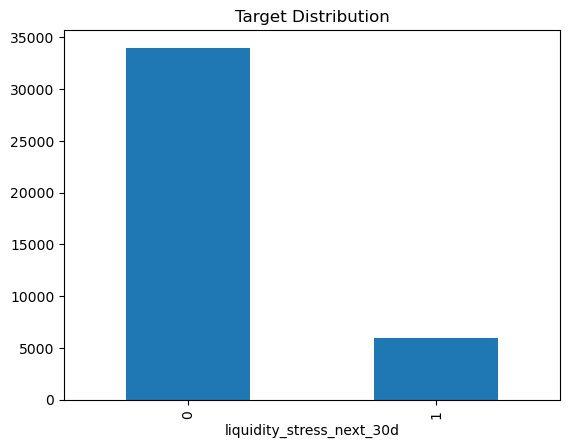

In [10]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

In [11]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Series([], dtype: int64)

In [14]:
for col in train.select_dtypes(include="object").columns:
    print(col)
    print(train[col].value_counts())
    print("-"*30)

gender
gender
F    23908
M    16092
Name: count, dtype: int64
------------------------------
region
region
Coastal & Eastern Corridor    8776
Southern Highlands            7280
Northern Highlands            6412
Lake Zone (Northwest)         5368
Central Zone                  5044
Western Zone                  4536
Islander                      2584
Name: count, dtype: int64
------------------------------
smartphone
smartphone
Yes    21956
No     18044
Name: count, dtype: int64
------------------------------
segment
segment
MVC    20532
LVC    15732
HVC     3736
Name: count, dtype: int64
------------------------------
earning_pattern
earning_pattern
Weekly Earner       24116
Monthly Earner       9844
Irregular Earner     6040
Name: count, dtype: int64
------------------------------
ID
ID
ID_F5946D40CB    1
ID_9BCC7CB4FB    1
ID_BF32437E46    1
ID_2A5467AF05    1
ID_88512AA80C    1
                ..
ID_20EB501231    1
ID_CFD8F26581    1
ID_D40D58FC67    1
ID_CB8B764D76    1
ID_C1DF84C4

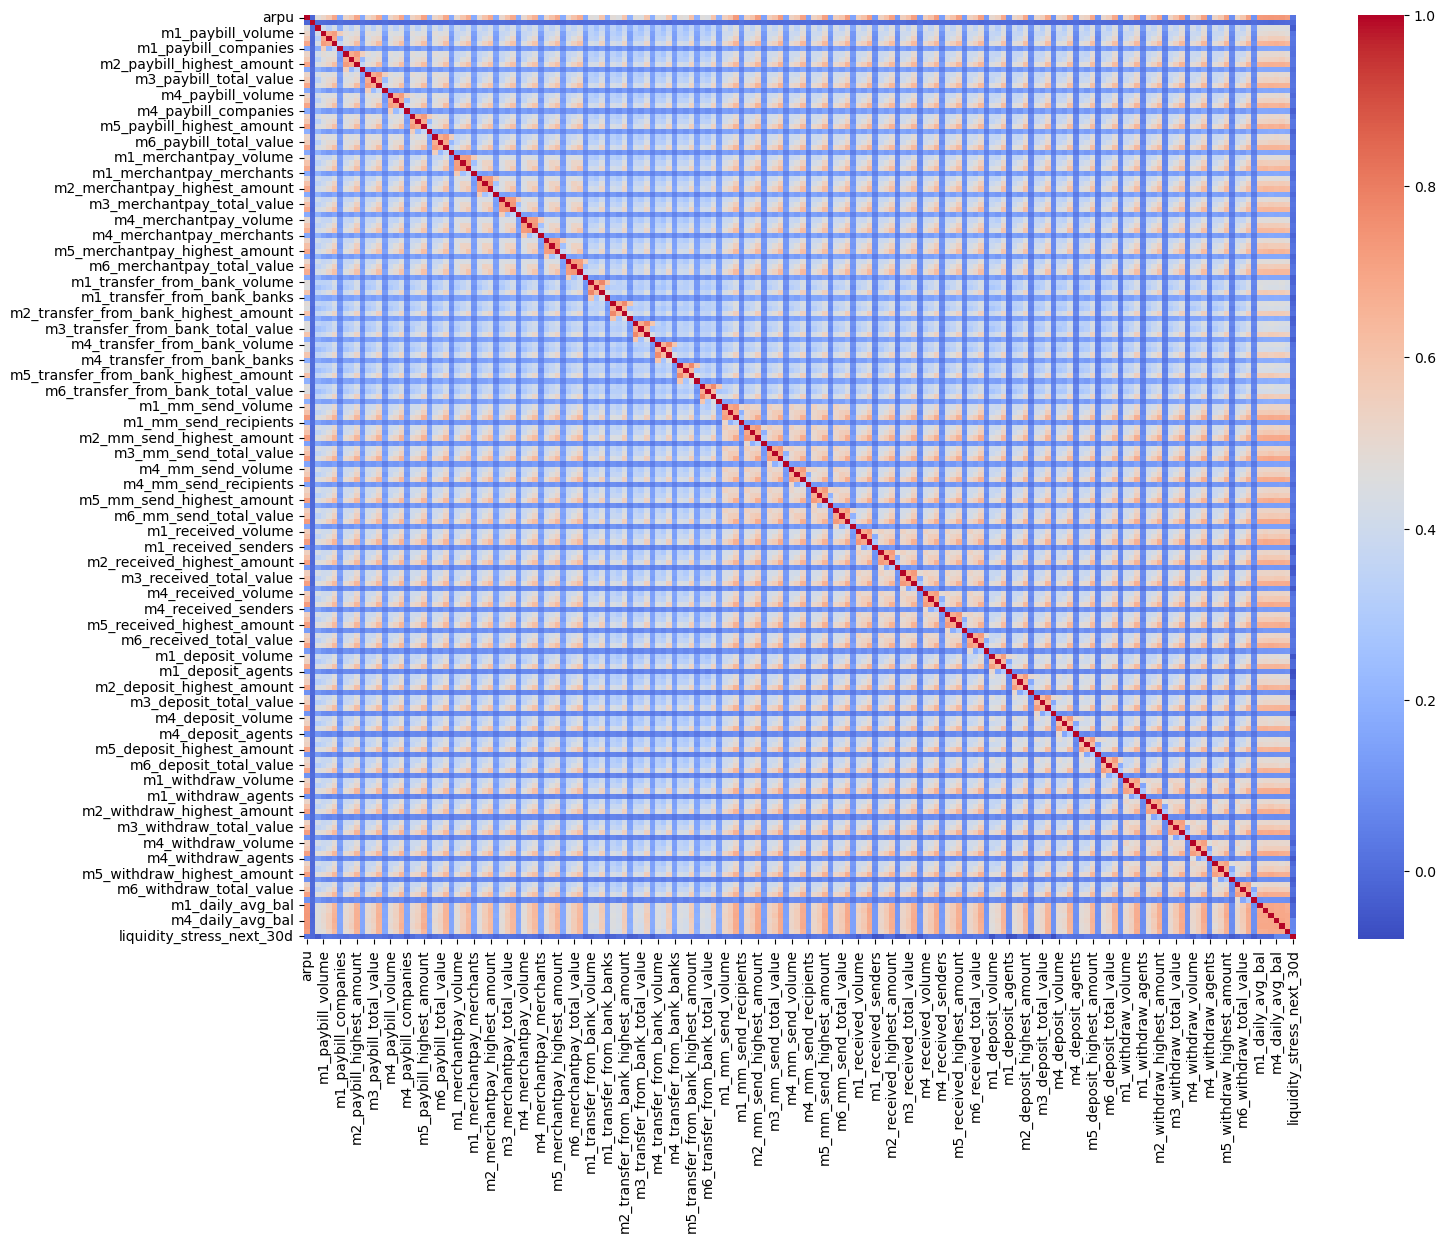

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_train = train.select_dtypes(include=["number"])

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_train.corr(), cmap="coolwarm")
plt.show()

In [17]:
numeric_train = train.select_dtypes(include=["number"])

corr_with_target = numeric_train.corr()["liquidity_stress_next_30d"].sort_values(ascending=False)
print(corr_with_target.head(20))
print(corr_with_target.tail(20))

liquidity_stress_next_30d     1.000000
m6_daily_avg_bal              0.076690
m5_daily_avg_bal              0.072168
m4_daily_avg_bal              0.070079
m1_withdraw_volume            0.041631
m3_mm_send_total_value        0.033682
m3_withdraw_volume            0.032999
m4_deposit_total_value        0.032165
m5_deposit_total_value        0.032065
m3_withdraw_total_value       0.031102
m2_withdraw_volume            0.030917
m5_deposit_highest_amount     0.030817
m1_withdraw_total_value       0.030351
m6_mm_send_total_value        0.030344
m5_deposit_agents             0.030232
m1_withdraw_highest_amount    0.029132
m5_mm_send_highest_amount     0.029070
m4_received_total_value       0.028500
m1_paybill_total_value        0.027930
m6_deposit_total_value        0.027646
Name: liquidity_stress_next_30d, dtype: float64
m4_paybill_companies          -0.030562
m1_received_volume            -0.033057
m3_transfer_from_bank_banks   -0.034669
m1_transfer_from_bank_banks   -0.035197
m2_transfer_

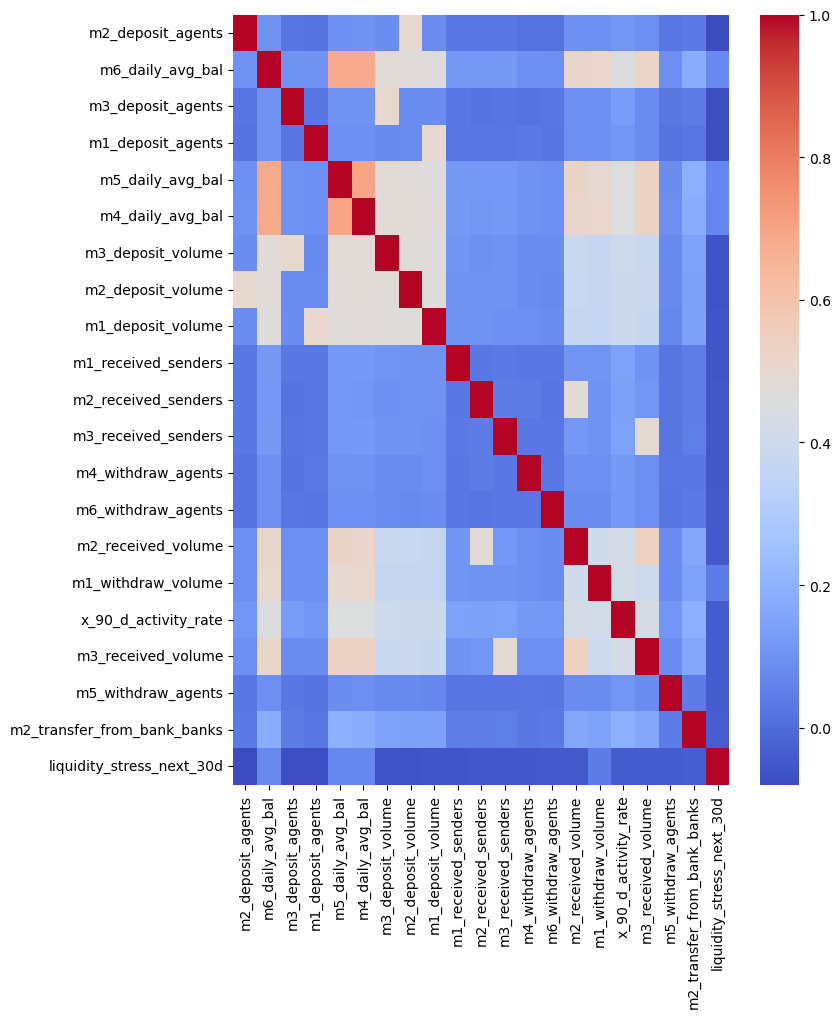

In [18]:
top_corr = corr_with_target.drop("liquidity_stress_next_30d").abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(8, 10))
sns.heatmap(numeric_train[top_corr.tolist() + ["liquidity_stress_next_30d"]].corr(), cmap="coolwarm", annot=False)
plt.show()

### 1. 🔥 Balance Trend (VERY IMPORTANT)

In [19]:
X["balance_trend"] = X["m6_daily_avg_bal"] - X["m1_daily_avg_bal"]
test["balance_trend"] = test["m6_daily_avg_bal"] - test["m1_daily_avg_bal"]

2. 💰 Total Balance Across 6 Months

In [20]:
bal_cols = [f"m{i}_daily_avg_bal" for i in range(1,7)]

X["balance_mean"] = X[bal_cols].mean(axis=1)
X["balance_std"] = X[bal_cols].std(axis=1)

test["balance_mean"] = test[bal_cols].mean(axis=1)
test["balance_std"] = test[bal_cols].std(axis=1)

3. 🔄 Inflow vs Outflow Ratio

In [21]:
X["cash_ratio"] = X["m1_paybill_total_value"] / (X["m1_withdraw_total_value"] + 1)
test["cash_ratio"] = test["m1_paybill_total_value"] / (test["m1_withdraw_total_value"] + 1)

4. 📉 Withdrawal Intensity

In [22]:
X["withdraw_intensity"] = X["m1_withdraw_total_value"] / (X["m1_withdraw_volume"] + 1)
test["withdraw_intensity"] = test["m1_withdraw_total_value"] / (test["m1_withdraw_volume"] + 1)